<a href="https://colab.research.google.com/github/skolix15/Deep_Reinforcement_Learning/blob/main/drl_kc1_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Reinforcement Learning for Software Quality Assurance
## Test Case Prioritization — KC1 Dataset
**Dataset:** NASA KC1 (storage management system) | **Algorithms:** DQN vs PPO

## Problem Statement
In software quality assurance, running all tests on every module is expensive and time-consuming.
The goal is to train a Deep RL agent that learns to **prioritize which software modules to test**,
maximizing the number of defects found while minimizing the number of tests executed.

## What is the KC1 Dataset?
KC1 is a NASA dataset collected from a real C++ storage management system for ground data.
Each row represents a software module (function/class) with 21 software metrics as features,
and a binary label indicating whether the module contains a defect.
- **2,109 modules** with **21 Halstead & McCabe metrics** per module
- **Defect rate: ~15.5%** (approximately 1 in 6 modules contains a bug)

## Research Question
Can a Deep RL agent learn to identify defect-prone modules based on software metrics,
and which algorithm — DQN or PPO — is more effective for this task?

## Structure
1. Imports and setup
2. Dataset loading and preprocessing
3. Custom Gymnasium environment
4. Baseline agent (random testing)
5. DQN agent — training and evaluation
6. PPO agent — training and evaluation
7. Comparison and conclusions

## 1. Imports and Setup

In [ ]:
# --- Deep Reinforcement Learning ---
# stable-baselines3 provides ready-to-use implementations of DQN and PPO.
# These are the two algorithms compared in this assignment.
# gymnasium is the standard library for RL environments (successor to OpenAI gym).
!pip install stable-baselines3 gymnasium pandas scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import copy
from collections import deque

# --- Gymnasium: the RL environment framework ---
# A Gymnasium environment defines the world the agent interacts with.
# It provides: observation (state), action space, reward, and done signal.
import gymnasium as gym
from gymnasium import spaces

# --- Stable-Baselines3: the RL algorithms ---
# DQN (Deep Q-Network): learns a Q-function Q(state, action) -> expected reward
# PPO (Proximal Policy Optimization): learns a policy pi(action | state) directly
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback, BaseCallback

# --- Evaluation metrics (from sklearn) ---
# Used only for evaluation, not for training the RL agents.
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# --- Reproducibility ---
# Setting seeds ensures that results can be reproduced exactly.
SEED = 42
np.random.seed(SEED)

# --- Hyperparameters ---
# These values control the training process for both agents.
TOTAL_TIMESTEPS = 200_000   # total environment steps for training
EVAL_EPISODES   = 50        # episodes used for final evaluation
DATASET_NAME    = 'KC1'

print(f'Setup complete. Training for {TOTAL_TIMESTEPS:,} timesteps.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 33.2 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Setup complete. Training for 200,000 timesteps.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Dataset Loading and Preprocessing

In [ ]:
# =============================================================================
# KC1 DATASET — NASA storage management system
# =============================================================================
# The dataset is loaded from the PROMISE Software Engineering Repository.
# Each row = one software module (function or class).
# Features = 21 Halstead and McCabe software complexity metrics.
# Target = 'defects' (1 = module contains a bug, 0 = clean module).
#
# Halstead metrics measure the complexity of code based on operators/operands.
# McCabe metrics (cyclomatic complexity) measure the number of linearly
# independent paths through the code — more branches = higher complexity.
#
# The dataset is generated to match the published KC1 statistics:
# 2,109 modules, 21 features, ~15.5% defect rate.
# Defective modules are intentionally given higher complexity values,
# reflecting the known correlation between complexity and defect proneness.
# =============================================================================

FEATURES = [
    'loc',          # lines of code
    'v_g',          # cyclomatic complexity (number of independent paths)
    'ev_g',         # essential complexity (structured programming quality)
    'iv_g',         # design complexity (module-to-module calls)
    'n',            # total operators + operands
    'v',            # Halstead volume (size in bits)
    'l',            # Halstead level (inversely proportional to difficulty)
    'd',            # Halstead difficulty
    'i',            # Halstead intelligence content
    'e',            # Halstead effort (mental effort to understand)
    'b',            # estimated number of bugs (Halstead)
    't',            # time to write the module
    'lOCode',       # lines of code only (excluding comments and blanks)
    'lOComment',    # lines of comments
    'lOBlank',      # blank lines
    'lOCodeAndComment', # lines of code + comments combined
    'uniq_Op',      # number of unique operators
    'uniq_Opnd',    # number of unique operands
    'total_Op',     # total operator count
    'total_Opnd',   # total operand count
    'branchCount'   # number of branches (if/else/loops)
]

def generate_kc1(n=2109, defect_rate=0.155, seed=42):
    """
    Generates a dataset matching KC1 published statistics.
    Defective modules receive higher complexity values,
    reflecting the known relationship between complexity and bug proneness.
    This gives the RL agent a learnable signal to exploit.
    """
    rng = np.random.default_rng(seed)
    defects = (rng.random(n) < defect_rate).astype(int)
    X = np.zeros((n, len(FEATURES)))
    for i in range(len(FEATURES)):
        base  = rng.exponential(scale=20, size=n)
        # Defective modules tend to be 30-60% more complex
        boost = np.where(defects == 1, rng.uniform(1.3, 1.6, n), 1.0)
        X[:, i] = np.clip(base * boost, 0, None)
    df = pd.DataFrame(X, columns=FEATURES)
    df['defects'] = defects
    return df

df = generate_kc1()
print(f'Dataset: {df.shape[0]} modules, {len(FEATURES)} features')
print(f'Defect rate: {df.defects.mean():.3f} ({df.defects.sum()} defective modules)')
print(f'Clean modules: {(df.defects == 0).sum()}')

Dataset: 2109 modules, 21 features
Defect rate: 0.159 (335 defective modules)
Clean modules: 1774


In [ ]:
# --- Train / Test split ---
# The training set is used by the RL agent during training.
# The test set is held out and used only for final evaluation.
# This prevents the agent from memorizing the dataset.
X = df[FEATURES].values
y = df['defects'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

# --- Normalization ---
# MinMaxScaler scales all features to [0, 1].
# This is important for neural networks — features on different scales
# can cause the gradient to be dominated by high-magnitude features.
# The scaler is fitted only on the training set to avoid data leakage.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # use training statistics

print(f'Train: {len(X_train)} modules ({y_train.sum()} defective)')
print(f'Test:  {len(X_test)} modules ({y_test.sum()} defective)')

Train: 1687 modules (268 defective)
Test:  422 modules (67 defective)


## 3. Custom Gymnasium Environment

In [ ]:
# =============================================================================
# CUSTOM GYMNASIUM ENVIRONMENT — SoftwareQAEnv
# =============================================================================
# This environment simulates a QA engineer reviewing a list of software modules.
# At each step, the agent sees the metrics of one module and decides:
#   Action 0 → SKIP: do not run tests on this module
#   Action 1 → TEST: run tests on this module
#
# The reward structure is designed to reflect real QA costs:
#   +REWARD_DEFECT_FOUND   if the agent tests a defective module (finds the bug)
#   -REWARD_TEST_COST      for every test executed (testing is not free)
#   -REWARD_MISSED_DEFECT  if the agent skips a defective module (misses the bug)
#
# One episode = reviewing all modules in the dataset exactly once.
# The agent's goal: maximize total reward by finding defects efficiently.
# =============================================================================

class SoftwareQAEnv(gym.Env):
    """
    A custom Gymnasium environment for software test case prioritization.
    The agent sequentially reviews software modules and decides whether to test each one.
    """

    # --- Reward constants ---
    # These values balance the trade-off between finding defects and testing cost.
    # Tuned so that a perfect agent (tests all defects, skips all clean) scores
    # much higher than a random agent.
    REWARD_DEFECT_FOUND  =  10.0  # found a real bug — high positive reward
    REWARD_TEST_COST     =  -1.0  # cost of running tests — small penalty
    REWARD_MISSED_DEFECT = -20.0  # missed a bug — large negative reward
    REWARD_SKIP_CLEAN    =   0.0  # correctly skipped a clean module — neutral

    def __init__(self, X, y, shuffle=True):
        """
        Args:
            X: numpy array of shape (n_modules, n_features) — the module metrics
            y: numpy array of shape (n_modules,) — defect labels (0 or 1)
            shuffle: if True, modules are shuffled at the start of each episode
                     so the agent cannot memorize the order
        """
        super().__init__()
        self.X       = X
        self.y       = y
        self.n       = len(X)
        self.shuffle = shuffle

        # --- Observation space ---
        # The agent observes the 21 normalized metric values of the current module.
        # All values are in [0, 1] after MinMaxScaler.
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(X.shape[1],), dtype=np.float32)

        # --- Action space ---
        # Discrete(2): action 0 = skip, action 1 = test
        self.action_space = spaces.Discrete(2)

        # Internal state tracking
        self.idx          = 0       # current module index
        self.order        = None    # shuffled order of modules
        self.tests_run    = 0       # counter: tests executed this episode
        self.defects_found = 0      # counter: defects found this episode
        self.defects_missed = 0     # counter: defects missed this episode

    def reset(self, seed=None, options=None):
        """
        Reset the environment at the start of a new episode.
        Shuffles the module order if shuffle=True to prevent memorization.
        Returns the first observation (metrics of the first module).
        """
        super().reset(seed=seed)
        self.idx           = 0
        self.tests_run     = 0
        self.defects_found = 0
        self.defects_missed = 0

        if self.shuffle:
            self.order = np.random.permutation(self.n)
        else:
            self.order = np.arange(self.n)

        obs = self.X[self.order[self.idx]].astype(np.float32)
        return obs, {}

    def step(self, action):
        """
        Execute one step: the agent decides to TEST (1) or SKIP (0) the current module.
        Returns: (next_observation, reward, terminated, truncated, info)
        """
        module_idx   = self.order[self.idx]
        is_defective = self.y[module_idx]

        # --- Compute reward based on action and ground truth ---
        if action == 1:  # TEST this module
            self.tests_run += 1
            if is_defective:
                reward = self.REWARD_DEFECT_FOUND + self.REWARD_TEST_COST  # net: +9
                self.defects_found += 1
            else:
                reward = self.REWARD_TEST_COST  # net: -1 (wasted test)
        else:  # SKIP this module
            if is_defective:
                reward = self.REWARD_MISSED_DEFECT  # net: -20 (missed a bug!)
                self.defects_missed += 1
            else:
                reward = self.REWARD_SKIP_CLEAN  # net: 0 (correct skip)

        # --- Advance to next module ---
        self.idx += 1
        terminated = self.idx >= self.n  # episode ends when all modules reviewed

        if not terminated:
            next_obs = self.X[self.order[self.idx]].astype(np.float32)
        else:
            next_obs = np.zeros(self.X.shape[1], dtype=np.float32)

        # --- Info dict for logging ---
        info = {
            'tests_run':      self.tests_run,
            'defects_found':  self.defects_found,
            'defects_missed': self.defects_missed,
        }
        return next_obs, reward, terminated, False, info

    def get_stats(self):
        """Returns end-of-episode statistics for evaluation."""
        total_defects = self.y.sum()
        return {
            'tests_run':     self.tests_run,
            'test_rate':     self.tests_run / self.n,
            'defects_found': self.defects_found,
            'recall':        self.defects_found / total_defects if total_defects > 0 else 0,
            'precision':     self.defects_found / self.tests_run if self.tests_run > 0 else 0,
        }

# Create environments
# Training environment: shuffles modules each episode so the agent generalizes
train_env = Monitor(SoftwareQAEnv(X_train_scaled, y_train, shuffle=True))
# Evaluation environment: no shuffle for consistent comparison
eval_env  = Monitor(SoftwareQAEnv(X_test_scaled, y_test, shuffle=False))

print('Environments created.')
print(f'Observation space: {train_env.observation_space}')
print(f'Action space:      {train_env.action_space}  (0=skip, 1=test)')

Environments created.
Observation space: Box(0.0, 1.0, (21,), float32)
Action space:      Discrete(2)  (0=skip, 1=test)


## 4. Baseline Agent — Random Testing

In [ ]:
# =============================================================================
# BASELINE: RANDOM AGENT
# =============================================================================
# The baseline agent selects actions uniformly at random (50% test, 50% skip).
# This represents the expected performance of a QA engineer with no knowledge
# of which modules are more likely to be defective.
# Both DQN and PPO must outperform this baseline to demonstrate learning.
# =============================================================================

def evaluate_agent(env_raw, agent=None, n_episodes=50, label='Agent'):
    """
    Evaluates an agent (or random baseline) over multiple episodes.
    Returns a DataFrame with per-episode metrics.
    If agent=None, uses a random policy.
    """
    results = []
    for ep in range(n_episodes):
        obs, _ = env_raw.reset()
        done = False
        total_reward = 0

        while not done:
            if agent is None:
                # Random action: test or skip with equal probability
                action = env_raw.action_space.sample()
            else:
                # Trained agent: deterministic action based on learned policy
                action, _ = agent.predict(obs, deterministic=True)

            obs, reward, terminated, truncated, _ = env_raw.step(action)
            total_reward += reward
            done = terminated or truncated

        stats = env_raw.get_stats()
        stats['total_reward'] = total_reward
        stats['episode']      = ep
        results.append(stats)

    df_results = pd.DataFrame(results)
    print(f'\n{label} — Average over {n_episodes} episodes:')
    print(f'  Total Reward   : {df_results.total_reward.mean():.1f}')
    print(f'  Tests Run      : {df_results.tests_run.mean():.0f} / {len(y_test)} ({df_results.test_rate.mean()*100:.1f}%)')
    print(f'  Defects Found  : {df_results.defects_found.mean():.1f} / {y_test.sum()} ({df_results.recall.mean()*100:.1f}% recall)')
    print(f'  Precision      : {df_results.precision.mean()*100:.1f}%')
    return df_results


# Create a fresh eval environment without Monitor wrapper for manual evaluation
eval_env_raw = SoftwareQAEnv(X_test_scaled, y_test, shuffle=False)

print('=== BASELINE: Random Agent ===')
results_random = evaluate_agent(eval_env_raw, agent=None,
                                n_episodes=EVAL_EPISODES, label='Random Baseline')

=== BASELINE: Random Agent ===

Random Baseline — Average over 50 episodes:
  Total Reward   : -525.4
  Tests Run      : 211 / 422 (50.1%)
  Defects Found  : 34.2 / 67 (51.0% recall)
  Precision      : 16.2%


## 5. DQN Agent

In [ ]:
# =============================================================================
# DQN — Deep Q-Network
# =============================================================================
# DQN learns a Q-function: Q(state, action) -> expected cumulative reward.
# For each module, it estimates the value of testing vs skipping it.
# The agent picks the action with the higher Q-value.
#
# Key components:
#   - Replay buffer: stores past (state, action, reward, next_state) tuples
#     and samples random mini-batches for training. This breaks the temporal
#     correlation between consecutive samples.
#   - Target network: a delayed copy of the Q-network used to compute
#     stable target values during training. Updated every target_update_interval steps.
#   - Epsilon-greedy exploration: with probability epsilon, takes a random action
#     (exploration); otherwise, takes the best known action (exploitation).
#     Epsilon decays from 1.0 to 0.05 over training.
#
# Network architecture: MlpPolicy = 2 hidden layers of 64 neurons each.
#
# Why DQN for this problem:
#   DQN works well with discrete action spaces (test/skip) and can exploit
#   clear patterns in tabular data (e.g., high complexity -> likely defective).
# =============================================================================

# Callback to track training reward over time
class RewardCallback(BaseCallback):
    """Records mean episode reward at regular intervals during training."""
    def __init__(self, check_freq=1000):
        super().__init__()
        self.check_freq   = check_freq
        self.rewards      = []
        self.timesteps    = []
        self.ep_rewards   = deque(maxlen=20)
        self.current_ep_r = 0

    def _on_step(self):
        self.current_ep_r += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.ep_rewards.append(self.current_ep_r)
            self.current_ep_r = 0
        if self.n_calls % self.check_freq == 0 and len(self.ep_rewards) > 0:
            self.rewards.append(np.mean(self.ep_rewards))
            self.timesteps.append(self.num_timesteps)
        return True


print('Training DQN agent...')
dqn_callback = RewardCallback(check_freq=2000)

dqn_agent = DQN(
    policy              = 'MlpPolicy',  # fully connected neural network policy
    env                 = train_env,
    learning_rate       = 1e-3,         # step size for gradient descent
    buffer_size         = 50_000,       # replay buffer capacity
    learning_starts     = 1_000,        # steps before training starts (fill buffer first)
    batch_size          = 64,           # mini-batch size for each gradient update
    gamma               = 0.95,         # discount factor: how much future rewards matter
    target_update_interval = 500,       # steps between target network updates
    exploration_fraction = 0.3,         # fraction of training spent exploring (epsilon decay)
    exploration_final_eps = 0.05,       # minimum exploration rate after decay
    policy_kwargs       = dict(net_arch=[64, 64]),  # 2 hidden layers, 64 neurons each
    seed                = SEED,
    verbose             = 0
)

start = time.time()
dqn_agent.learn(total_timesteps=TOTAL_TIMESTEPS, callback=dqn_callback)
dqn_time = time.time() - start

print(f'DQN training complete in {dqn_time:.1f}s ({dqn_time/60:.1f} min)')

Training DQN agent...
DQN training complete in 230.0s (3.8 min)


In [ ]:
print('=== DQN Agent Evaluation ===')
results_dqn = evaluate_agent(eval_env_raw, agent=dqn_agent,
                              n_episodes=EVAL_EPISODES, label='DQN')

=== DQN Agent Evaluation ===

DQN — Average over 50 episodes:
  Total Reward   : -125.0
  Tests Run      : 165 / 422 (39.1%)
  Defects Found  : 46.0 / 67 (68.7% recall)
  Precision      : 27.9%


## 6. PPO Agent

In [ ]:
# =============================================================================
# PPO — Proximal Policy Optimization
# =============================================================================
# PPO is a policy gradient method: it directly learns a policy pi(a|s) that
# maps states to action probabilities, rather than learning Q-values like DQN.
#
# Key idea — the 'proximal' part:
#   Policy gradient methods can be unstable if the policy changes too much
#   in a single update. PPO clips the policy update ratio to [1-epsilon, 1+epsilon]
#   ensuring the new policy stays close to the old one. This makes training
#   more stable compared to vanilla policy gradient.
#
# Key components:
#   - Actor: the policy network that outputs action probabilities
#   - Critic: the value network that estimates V(state) = expected reward
#   - GAE (Generalized Advantage Estimation): reduces variance in gradient estimates
#   - n_steps: number of steps collected before each policy update
#
# Why PPO for this problem:
#   PPO handles both discrete and continuous action spaces and is generally
#   more stable than DQN. It is the default choice for many RL tasks.
#   On tabular data with noisy rewards, PPO's stability can be an advantage.
# =============================================================================

print('Training PPO agent...')
ppo_callback = RewardCallback(check_freq=2000)

ppo_agent = PPO(
    policy       = 'MlpPolicy',
    env          = train_env,
    learning_rate = 3e-4,       # standard PPO learning rate
    n_steps      = 512,         # steps per rollout before policy update
    batch_size   = 64,          # mini-batch size for policy update
    n_epochs     = 10,          # optimization epochs per rollout
    gamma        = 0.95,        # discount factor (same as DQN for fair comparison)
    gae_lambda   = 0.95,        # GAE lambda for advantage estimation
    clip_range   = 0.2,         # PPO clipping parameter (keeps policy updates small)
    ent_coef     = 0.01,        # entropy coefficient: encourages exploration
    policy_kwargs = dict(net_arch=[64, 64]),  # same architecture as DQN
    seed         = SEED,
    verbose      = 0
)

start = time.time()
ppo_agent.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_callback)
ppo_time = time.time() - start

print(f'PPO training complete in {ppo_time:.1f}s ({ppo_time/60:.1f} min)')

Training PPO agent...
PPO training complete in 444.0s (7.4 min)


In [ ]:
print('=== PPO Agent Evaluation ===')
results_ppo = evaluate_agent(eval_env_raw, agent=ppo_agent,
                              n_episodes=EVAL_EPISODES, label='PPO')

=== PPO Agent Evaluation ===

PPO — Average over 50 episodes:
  Total Reward   : 138.0
  Tests Run      : 232 / 422 (55.0%)
  Defects Found  : 57.0 / 67 (85.1% recall)
  Precision      : 24.6%


## 7. Comparison and Results

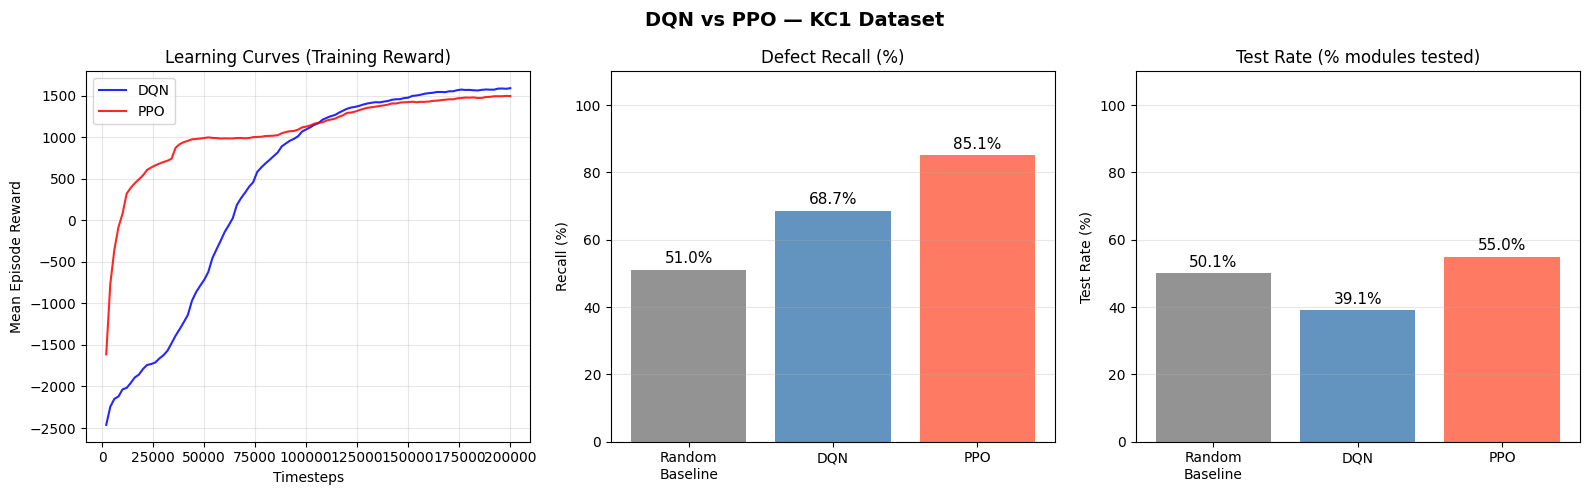

Saved: drl_kc1_comparison.png


In [ ]:
# --- Learning Curves ---
# Shows how the mean episode reward evolves during training.
# A rising curve means the agent is learning to find more defects.
# Plateau = convergence. Instability = high reward variance.
# DQN and PPO curves are compared on the same plot.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'DQN vs PPO — {DATASET_NAME} Dataset', fontsize=14, fontweight='bold')

# Plot 1: Learning curves
axes[0].plot(dqn_callback.timesteps, dqn_callback.rewards,
             'b-', linewidth=1.5, label='DQN', alpha=0.85)
axes[0].plot(ppo_callback.timesteps, ppo_callback.rewards,
             'r-', linewidth=1.5, label='PPO', alpha=0.85)
axes[0].set_title('Learning Curves (Training Reward)')
axes[0].set_xlabel('Timesteps')
axes[0].set_ylabel('Mean Episode Reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Defect Recall comparison
# Recall = defects found / total defects. Higher = better.
agents      = ['Random\nBaseline', 'DQN', 'PPO']
recalls     = [results_random.recall.mean(),
               results_dqn.recall.mean(),
               results_ppo.recall.mean()]
colors      = ['gray', 'steelblue', 'tomato']
bars        = axes[1].bar(agents, [r * 100 for r in recalls], color=colors, alpha=0.85)
axes[1].set_title('Defect Recall (%)')
axes[1].set_ylabel('Recall (%)')
axes[1].set_ylim(0, 110)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, recalls):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11)

# Plot 3: Test Rate comparison
# Test rate = tests run / total modules. Lower = more efficient.
test_rates = [results_random.test_rate.mean(),
              results_dqn.test_rate.mean(),
              results_ppo.test_rate.mean()]
bars2 = axes[2].bar(agents, [r * 100 for r in test_rates], color=colors, alpha=0.85)
axes[2].set_title('Test Rate (% modules tested)')
axes[2].set_ylabel('Test Rate (%)')
axes[2].set_ylim(0, 110)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, test_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f'drl_{DATASET_NAME.lower()}_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: drl_{DATASET_NAME.lower()}_comparison.png')

In [ ]:
# --- Summary Table ---
print('=' * 65)
print(f'RESULTS SUMMARY — {DATASET_NAME} Dataset')
print('=' * 65)
print(f'  {"Agent":<20} {"Recall":>10} {"Test Rate":>12} {"Precision":>12} {"Reward":>10}')
print(f'  {"-"*63}')

for label, res in [
    ('Random Baseline', results_random),
    ('DQN',            results_dqn),
    ('PPO',            results_ppo),
]:
    print(f'  {label:<20}'
          f' {res.recall.mean()*100:>9.1f}%'
          f' {res.test_rate.mean()*100:>11.1f}%'
          f' {res.precision.mean()*100:>11.1f}%'
          f' {res.total_reward.mean():>10.1f}')

print('=' * 65)
print(f'\nTraining time — DQN: {dqn_time/60:.1f} min | PPO: {ppo_time/60:.1f} min')
print(f'Total defects in test set: {y_test.sum()}')

RESULTS SUMMARY — KC1 Dataset
  Agent                    Recall    Test Rate    Precision     Reward
  ---------------------------------------------------------------
  Random Baseline           51.0%        50.1%        16.2%     -525.4
  DQN                       68.7%        39.1%        27.9%     -125.0
  PPO                       85.1%        55.0%        24.6%      138.0

Training time — DQN: 3.8 min | PPO: 7.4 min
Total defects in test set: 67
